# **LO2 – Visual Perception**

In [2]:
# === LO2: Visual Perception ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data from GitHub ---
base_url = "https://raw.githubusercontent.com/rodrigourech/gdv/main/"
tas45 = pd.read_csv(base_url + "RCP45_tas.csv")
tas85 = pd.read_csv(base_url + "RCP85_tas.csv")
tas = pd.concat([tas45, tas85], ignore_index=True)

# --- Preprocess ---
tas["scenario"] = tas["scenario"].astype("category")
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month
tas["doy"] = tas["date"].dt.dayofyear
tas["decade"] = (tas["year"] // 10) * 10

# --- Subsets ---
stations = ["Zürich", "Lugano", "Davos"]
tas_s = tas[tas["station"].isin(stations)].copy()
tas85_zurich = tas[(tas["station"] == "Zürich") & (tas["scenario"] == "RCP85")].copy()


/tmp/ipython-input-1241706393.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ann = tas.groupby(["scenario", "year"], as_index=False)["value"].mean()


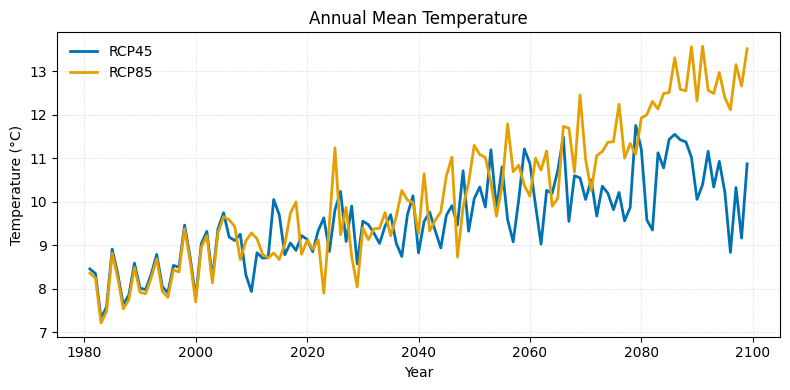

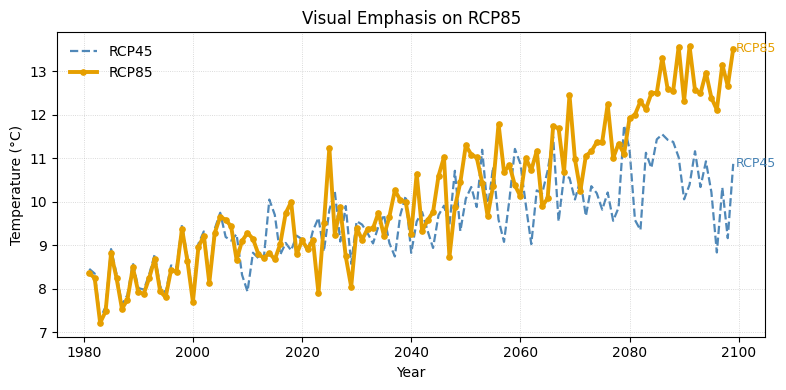

In [4]:
# ==============================
# Prepare annual data
# ==============================
ann = tas.groupby(["scenario", "year"], as_index=False)["value"].mean()
ann = ann.rename(columns={"value": "tas_ann_mean"})

# ==============================
# Plot A1: Neutral line chart (gleiches Gewicht, accessible)
# ==============================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

# farbsehschwächen-taugliche, kontrastreiche Farben (Okabe–Ito)
colors_neutral = {"RCP45": "#0072B2",  # kräftiges Blau
                  "RCP85": "#E69F00"}  # kräftiges Orange

for scen in ["RCP45", "RCP85"]:
    data = ann[ann["scenario"] == scen]
    ax.plot(
        data["year"], data["tas_ann_mean"],
        label=scen,
        color=colors_neutral[scen],
        linestyle="-",
        linewidth=2.0,
        alpha=1.0,
        zorder=2
    )

ax.set_title("Annual Mean Temperature")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

# ==============================
# Plot A2: Visual emphasis on RCP85 (figure–ground)
# ==============================
fig, ax = plt.subplots(figsize=(8, 4))

# De-emphasis: RCP4.5 in steelblue, gestrichelt, dünner
data45 = ann[ann["scenario"] == "RCP45"]
ax.plot(
    data45["year"], data45["tas_ann_mean"],
    label="RCP45",
    color="steelblue",          # dezent, aber gut lesbar (nicht "lightblue")
    linestyle="--",
    linewidth=1.6,
    alpha=0.95,
    marker=None,
    zorder=1
)

# Emphasis: RCP8.5 in dunklem Orange, dicker + Kreis-Marker
data85 = ann[ann["scenario"] == "RCP85"]
ax.plot(
    data85["year"], data85["tas_ann_mean"],
    label="RCP85",
    color="#E69F00",            # dunkles Orange (Okabe–Ito)
    linestyle="-",
    linewidth=2.8,
    alpha=1.0,
    marker="o",
    markersize=3.8,
    zorder=3
)

# Endlabels (redundant zur Legende, steigert Lesbarkeit)
for scen, df_s, col in [("RCP45", data45, "steelblue"), ("RCP85", data85, "#E69F00")]:
    x, y = df_s["year"].iloc[-1], df_s["tas_ann_mean"].iloc[-1]
    ax.text(x + 0.5, y, scen, color=col, va="center", fontsize=9)

ax.set_title("Visual Emphasis on RCP85")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

# Legende kann bleiben (oder ausblenden, wenn Endlabels genügen)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()


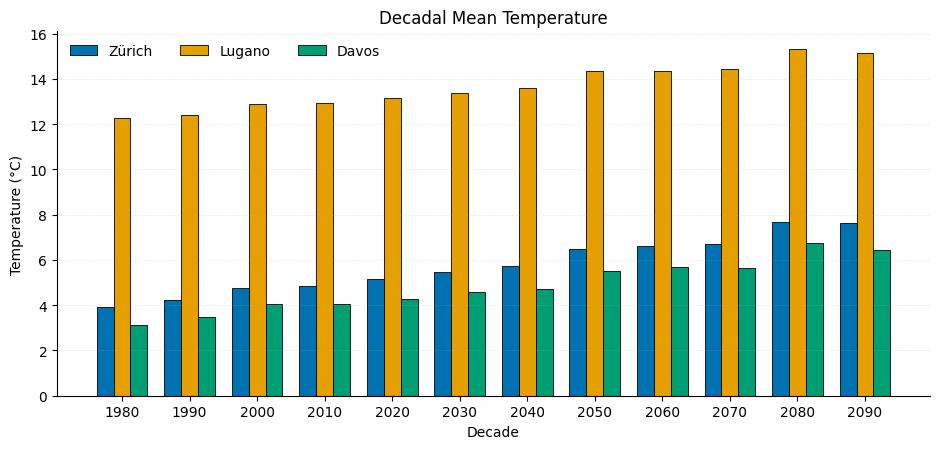

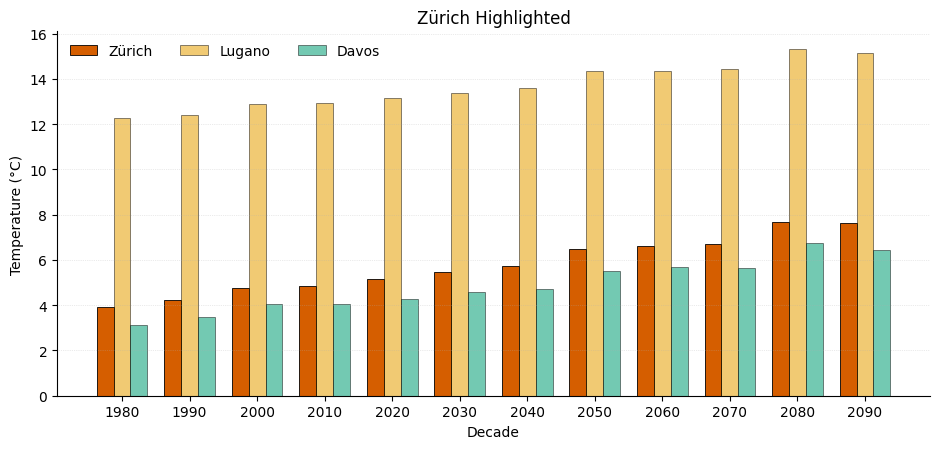

In [8]:
# ================================
# Datenaufbereitung
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tas = tas.copy()
tas["decade"] = (tas["year"] // 10) * 10
decadal = (
    tas.groupby(["decade", "station"], as_index=False)["value"]
       .mean()
       .rename(columns={"value": "tas_dec_mean"})
)

stations = ["Zürich", "Lugano", "Davos"]  # Reihenfolge für die Balkengruppen
decades  = np.array(sorted(decadal["decade"].unique()))
x        = np.arange(len(decades))        # Gruppenpositionen (eine pro Dekade)
bar_w    = 0.25                           # Breite je Balken


# =========================================
# Decadal Mean Temperature (Basic)
# =========================================
colors = {"Zürich": "#0072B2",   # blue
          "Lugano": "#E69F00",   # orange
          "Davos":  "#009E73"}   # green

fig, ax = plt.subplots(figsize=(9.5, 4.6))

for i, st in enumerate(stations):
    sub = (decadal[decadal["station"] == st]
           .set_index("decade")
           .reindex(decades)["tas_dec_mean"])
    ax.bar(
        x + (i - 1)*bar_w, sub.values, width=bar_w,
        label=st, color=colors[st],
        edgecolor="black", linewidth=0.6
    )

ax.set_title("Decadal Mean Temperature")
ax.set_xlabel("Decade")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in decades])
ax.legend(frameon=False, ncol=3)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.5)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# =========================================
# Zürich Highlighted
# =========================================
highlight = "Zürich"

# Farbmapping für Highlight-Variante
hl_colors = {"Zürich": "#D55E00",  # vermilion (kräftig)
             "Lugano": "#E69F00",  # orange
             "Davos":  "#009E73"}  # green

fig, ax = plt.subplots(figsize=(9.5, 4.6))

for i, st in enumerate(stations):
    sub = (decadal[decadal["station"] == st]
           .set_index("decade")
           .reindex(decades)["tas_dec_mean"])
    ax.bar(
        x + (i - 1)*bar_w, sub.values, width=bar_w,
        color=hl_colors[st],
        alpha=1.0 if st == highlight else 0.55,   # andere Städte bleiben sichtbar
        label=st,
        edgecolor="black", linewidth=0.6,
        hatch="" if st == highlight else None      # optional: Hatch weglassen für Fokus
    )

ax.set_title("Zürich Highlighted")
ax.set_xlabel("Decade")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in decades])
ax.legend(frameon=False, ncol=3)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.5)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()




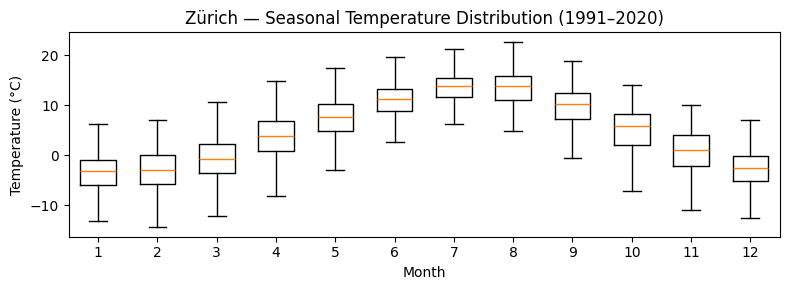

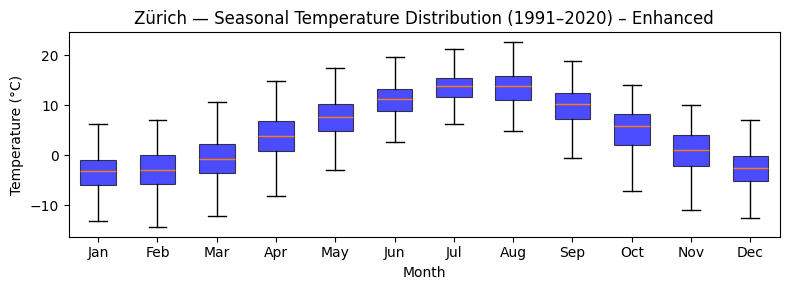

In [6]:
# === Vorbereitung: Datum, Jahr, Monat extrahieren ===
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month

# === Subset für gewählte Station ===
chosen_station = "Zürich"
tas_s = tas[tas["station"] == chosen_station]

# === Baseline-Zeitraum festlegen ===
BASELINE_YEARS = (1991, 2020)  # falls noch nicht definiert
y0, y1 = BASELINE_YEARS
base = tas_s[(tas_s["year"] >= y0) & (tas_s["year"] <= y1)]

# === Monatliche Verteilung vorbereiten ===
data_by_month = [base[base["month"] == m]["value"].dropna().values for m in range(1, 13)]

# === LO2 – Figure 2: Seasonal Boxplot – Before Version ===
def plot_fig2_before():
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.boxplot(data_by_month, positions=range(1, 13), widths=0.6, showfliers=False)
    ax.set_title(f"{chosen_station} — Seasonal Temperature Distribution ({y0}–{y1})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Temperature (°C)")
    ax.set_xticks(range(1, 13))
    fig.tight_layout()
    plt.show()

# === LO2 – Figure 2: Seasonal Boxplot – After Version ===
def plot_fig2_after():
    fig, ax = plt.subplots(figsize=(8, 3))
    bp = ax.boxplot(data_by_month, positions=range(1, 13), widths=0.6, showfliers=False, patch_artist=True)

    # Perzeptuelle Verbesserungen
    for patch in bp['boxes']:
        patch.set_facecolor("blue")
        patch.set_alpha(0.7)
        patch.set_linewidth(0.8)

    ax.set_title(f"{chosen_station} — Seasonal Temperature Distribution ({y0}–{y1}) – Enhanced")
    ax.set_xlabel("Month")
    ax.set_ylabel("Temperature (°C)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    fig.tight_layout()
    plt.show()

# === Beide Varianten ausführen ===
plot_fig2_before()
plot_fig2_after()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Parse and extract date components (if not done already) ===
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month
tas["doy"] = tas["date"].dt.dayofyear

# === Subset: RCP85 data for selected station ===
tas85_s = tas[(tas["station"] == chosen_station) & (tas["scenario"] == "RCP85")].copy()

# === Pivot to year × day-of-year matrix ===
mat = tas85_s.pivot_table(index="year", columns="doy", values="value", aggfunc="mean")

# === LO2 – Figure 4: Before Version (basic heatmap) ===
def plot_fig4_before():
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(mat.values, aspect="auto", origin="lower")
    ax.set_title(f"{chosen_station} – Daily Temperatures (RCP85, raw)")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Year")
    fig.tight_layout()
    plt.show()

# === LO2 – Figure 4: After Version (enhanced heatmap) ===
def plot_fig4_after():
    mat_smooth = mat.rolling(3, axis=1, min_periods=1).mean()
    vmin, vmax = np.nanpercentile(mat_smooth.values, [2, 98])

    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(mat_smooth.values, aspect="auto", origin="lower",
                   cmap="RdYlBu_r", vmin=vmin, vmax=vmax)

    ax.set_title(f"{chosen_station} — Daily Temperature Heatmap (RCP85)")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Year")

    # Set tidy tick marks
    years = mat.index.values
    yticks = np.linspace(0, len(years)-1, 6, dtype=int)
    ax.set_yticks(yticks)
    ax.set_yticklabels(years[yticks])

    xticks = np.arange(0, 366, 61)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) for x in xticks])

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Temperature (°C)")

    fig.tight_layout()
    plt.show()

# === Run both versions ===
plot_fig4_before()
plot_fig4_after()
